In [1]:
import matplotlib.pyplot as plt
import numpy as np

from hadrana.loader import load_c2pt_per_nsquare, load_c2pt_fwd_per_nsquare

D251
D251: #configs = 2012, binsize = 1
[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127]

A654
A654: #configs = 2534, binsize = 1
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47]



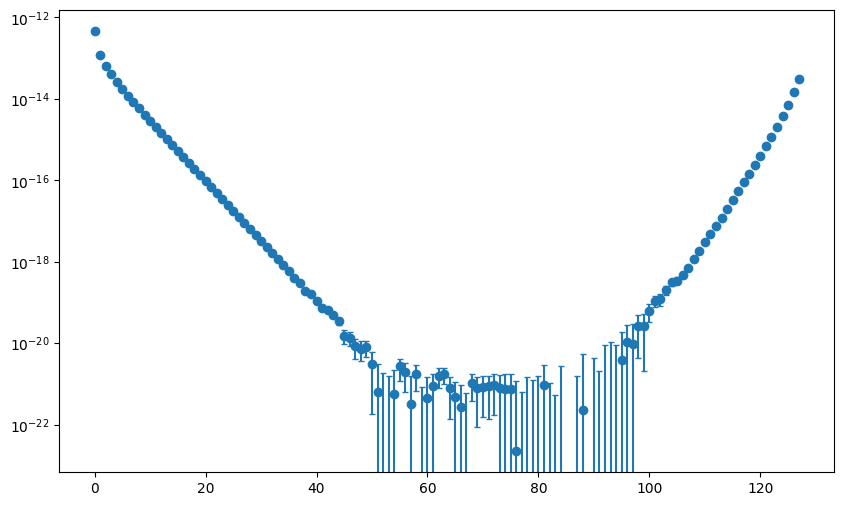

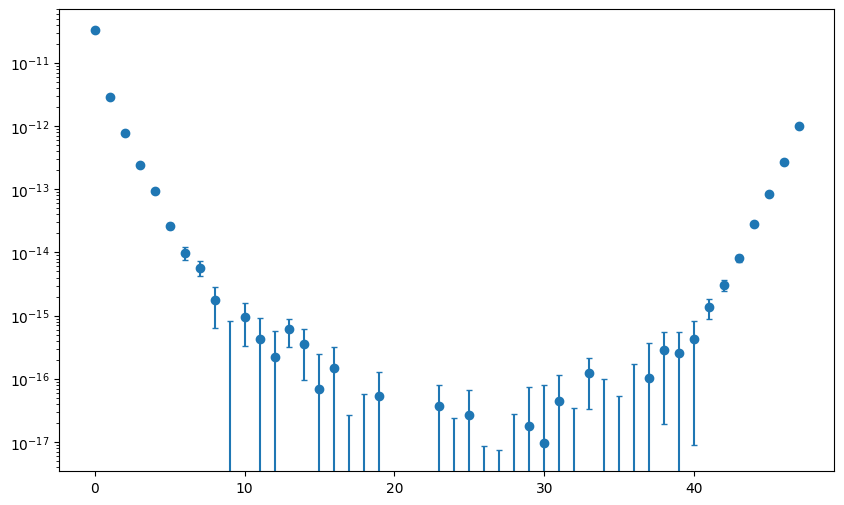

In [2]:
momentum_shells = [0, 1, 2, 3, 4, 5, 6, 8]
binsize = 1
nsquare = 0

for ensemble in ["D251", "A654"]:
    c2pt_per_nsquare = load_c2pt_per_nsquare(ensemble, momentum_shells, binsize) 

    c2pt = c2pt_per_nsquare[nsquare]
    ncfg = c2pt.shape[0]

    c2pt_avg = np.mean(c2pt, axis=0)
    c2pt_err = np.sqrt(ncfg - 1) * np.std(c2pt, axis=0, ddof=1)

    print(ensemble)
    print(f"{ensemble}: #configs = {ncfg}, binsize = {binsize}")

    fig, axs = plt.subplots(1, 1, figsize=(10, 6))

    nt = c2pt.shape[1]
    timeslices = np.arange(nt)

    print(timeslices)
    print()

    axs.errorbar(
        timeslices,
        c2pt_avg,
        c2pt_err,
        fmt='o',
        capsize=2,
    )

    axs.set_yscale("log")

nsquare=0  (binsize=2, nt=48)
------------------------------------------------------------------------------
    t |        fwd C   fwd SNR |        avg C   avg SNR | SNR avg/fwd
    0 |    3.254e-11    249.95 |    3.255e-11    250.41 |       1.002
    1 |    2.827e-12     85.61 |    2.837e-12    114.74 |       1.340
    2 |    7.618e-13     42.67 |    7.679e-13     61.37 |       1.438
    3 |    2.384e-13     23.40 |    2.451e-13     33.27 |       1.422
    4 |    9.719e-14     15.11 |    9.353e-14     21.27 |       1.407
    5 |    3.109e-14      6.86 |    2.661e-14      8.38 |       1.222
    6 |    1.436e-14      4.59 |    9.965e-15      4.34 |       0.948
    7 |    6.285e-15      3.14 |    5.744e-15      3.72 |       1.184
    8 |    2.113e-15      1.45 |    1.758e-15      1.56 |       1.071
    9 |    6.501e-16      0.56 |   -2.987e-17     -0.04 |      -0.062
   10 |    7.202e-16      0.89 |    9.618e-16      1.52 |       1.706
   11 |    1.182e-15      1.76 |    4.335e-16      

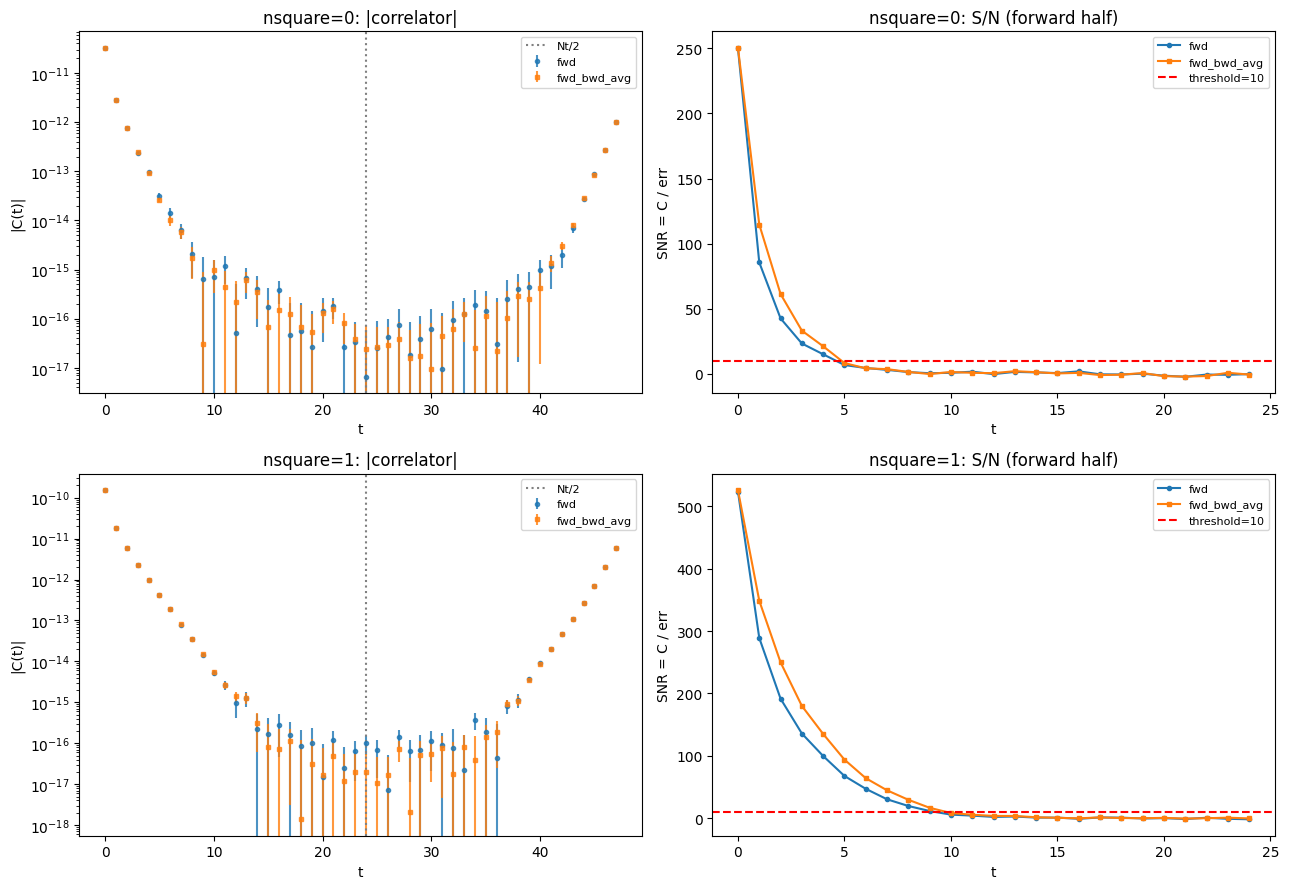

In [3]:
#!/usr/bin/env python3
"""
Settle whether `fwd_bwd_avg` is a proper FOLD or a diluting average.
 
Reads both pre-exported jackknife datasets for a shell:
    /c2pt/nsquare{ns}/fwd            (forward only)
    /c2pt/nsquare{ns}/fwd_bwd_avg    (0.5 * (fwd + bwd) as built in compute_c2pt.py)
 
A proper fold averages two independent FULL-signal estimates of the same decay,
so at small t it should improve S/N by ~sqrt(2) (ratio avg/fwd ~ 1.41) and give a
LATER (or equal) t_max than fwd alone.
 
If `bwd` is NOT time-reversed before the add, then at small t the forward signal
is averaged against the backward branch's NOISE FLOOR: the mean is ~halved and the
variance grows, so S/N gets WORSE and fwd alone yields a later t_max. In that case
the fwd_bwd_avg dataset is hurting you and you should fold properly or fit `fwd`.
"""
import h5py
import numpy as np
import matplotlib.pyplot as plt
 
from chigrad.statistics import compute_sdev   # same convention as the fit pipeline
 
# ----------------------------------------------------------------------
ensemble      = "A654"
binsize       = 2
shells        = [0, 1]          # the starved low shells; add more if you like
resample_type = "jackknife"
snr_threshold = 10
small_t_band  = (1, 5)          # forward-signal region used for the verdict
# ----------------------------------------------------------------------
 
path = (f"/hdd/data/ensemble_data/{ensemble}/c2pt/"
        f"{ensemble}_c2pt_binsize{binsize:02d}_jkn.h5")
 
 
def summarize(y):
    """jackknife central value, error (pipeline convention), and S/N per t."""
    cen = np.mean(y, axis=0)
    err = compute_sdev(y, resample_type)
    snr = cen / err
    return cen, err, snr
 
 
def t_max_like(snr, threshold=snr_threshold):
    """replicate estimate_maximum_timeslice: first t with SNR<=thr, minus one."""
    half  = len(snr) // 2
    below = np.where(snr[:half] <= threshold)[0]
    return int(below[0] - 1) if below.size else half - 1
 
 
fig, axes = plt.subplots(len(shells), 2, figsize=(13, 4.5 * len(shells)),
                         squeeze=False)
 
for row, ns in enumerate(shells):
    with h5py.File(path, "r") as f:
        fwd  = f[f"/c2pt/nsquare{ns:02d}/fwd"][()]
        favg = f[f"/c2pt/nsquare{ns:02d}/fwd_bwd_avg"][()]
 
    fwd_cen, fwd_err, fwd_snr = summarize(fwd)
    avg_cen, avg_err, avg_snr = summarize(favg)
 
    nt   = fwd_cen.shape[0]
    half = nt // 2
 
    tmax_fwd = t_max_like(fwd_snr)
    tmax_avg = t_max_like(avg_snr)
 
    lo, hi = small_t_band
    band   = np.arange(lo, hi + 1)
    # mean S/N ratio in the forward band (convention-independent)
    ratio_band = float(np.mean(avg_snr[band] / fwd_snr[band]))
 
    # ---- printed table -------------------------------------------------
    print("=" * 78)
    print(f"nsquare={ns}  (binsize={binsize}, nt={nt})")
    print("-" * 78)
    print(f"  {'t':>3s} | {'fwd C':>12s} {'fwd SNR':>9s} | "
          f"{'avg C':>12s} {'avg SNR':>9s} | {'SNR avg/fwd':>11s}")
    for t in range(0, half + 1):
        r = avg_snr[t] / fwd_snr[t] if fwd_snr[t] != 0 else np.nan
        print(f"  {t:3d} | {fwd_cen[t]:12.3e} {fwd_snr[t]:9.2f} | "
              f"{avg_cen[t]:12.3e} {avg_snr[t]:9.2f} | {r:11.3f}")
    print("-" * 78)
    print(f"  t_max(SNR<= {snr_threshold}):   fwd = {tmax_fwd}    "
          f"fwd_bwd_avg = {tmax_avg}")
    print(f"  mean SNR ratio (avg/fwd) over t in [{lo},{hi}] = {ratio_band:.3f}")
 
    # ---- verdict heuristic --------------------------------------------
    if ratio_band >= 1.25 and tmax_avg >= tmax_fwd:
        verdict = ("PROPER FOLD: avg ~sqrt(2) better at small t and t_max not "
                   "worse. bwd is reversed; keep using fwd_bwd_avg.")
    elif ratio_band <= 0.9 or tmax_fwd > tmax_avg:
        verdict = ("DILUTION: avg is WORSE at small t / fwd reaches later t_max. "
                   "bwd is NOT reversed before the add -> fold properly "
                   "(0.5*(C(t)+C(Nt-t))) or just fit the `fwd` dataset.")
    else:
        verdict = ("AMBIGUOUS: ratio between sqrt(2) and 1. Inspect the table and "
                   "the plot; bwd may be partially aligned or signal too weak.")
    print(f"  VERDICT: {verdict}")
    print("=" * 78 + "\n")
 
    # ---- plots ---------------------------------------------------------
    t = np.arange(nt)
    axL, axR = axes[row]
 
    axL.errorbar(t, np.abs(fwd_cen), yerr=fwd_err, fmt="o", ms=3,
                 label="fwd", alpha=0.8)
    axL.errorbar(t, np.abs(avg_cen), yerr=avg_err, fmt="s", ms=3,
                 label="fwd_bwd_avg", alpha=0.8)
    axL.set_yscale("log")
    axL.axvline(half, ls=":", color="grey", label="Nt/2")
    axL.set_xlabel("t")
    axL.set_ylabel("|C(t)|")
    axL.set_title(f"nsquare={ns}: |correlator|")
    axL.legend(fontsize=8)
 
    axR.plot(t[:half + 1], fwd_snr[:half + 1], "o-", ms=3, label="fwd")
    axR.plot(t[:half + 1], avg_snr[:half + 1], "s-", ms=3, label="fwd_bwd_avg")
    axR.axhline(snr_threshold, ls="--", color="red",
                label=f"threshold={snr_threshold}")
    axR.set_xlabel("t")
    axR.set_ylabel("SNR = C / err")
    axR.set_title(f"nsquare={ns}: S/N (forward half)")
    axR.legend(fontsize=8)
 
fig.tight_layout()
# out = f"fold_check_{ensemble}_binsize{binsize:02d}.png"
# fig.savefig(out, dpi=130)